#  Machine Learning



## Objectives

- Prepare the cleaned airline passenger satisfaction dataset for machine learning.
- Define the features and target variable.
- Encode categorical variables so they can be used by machine learning algorithms.
- Split the dataset into training and testing sets.
- Establish a baseline classification model.
- Train and evaluate suitable classification models.
- Compare model performance using appropriate classification metrics.
- Identify the most useful predictors of passenger satisfaction.
- Select a final model and explain why it was chosen.

## Inputs

- `data/clean_data/airline_clean.csv`

## Target Variable

- `satisfaction`

The target contains two classes:
- `satisfied`
- `neutral or dissatisfied`

This makes the project a **supervised binary classification problem**.

## Outputs

- Prepared training and testing datasets.
- Classification model performance results.
- Model comparison and evaluation.
- Identification of important predictors.
- A selected final model for predicting passenger satisfaction.



---

# Change working directory

In [1]:
import os

current_dir = os.getcwd()
current_dir

'c:\\Users\\hanee\\OneDrive\\Desktop\\Project2\\airline_passenger_satisfaction_analyst\\airline-passenger-satisfaction\\jupyter_notebooks'

In [2]:
if os.path.basename(os.getcwd()) == "airline_passenger_satisfaction_analyst":
    os.chdir("airline-passenger-satisfaction")
elif os.path.basename(os.getcwd()) == "jupyter_notebooks":
    os.chdir(os.path.dirname(os.getcwd()))

print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\hanee\OneDrive\Desktop\Project2\airline_passenger_satisfaction_analyst\airline-passenger-satisfaction


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\hanee\\OneDrive\\Desktop\\Project2\\airline_passenger_satisfaction_analyst\\airline-passenger-satisfaction'

## Load the Cleaned Dataset

Load the cleaned airline passenger satisfaction dataset and define the feature variables and target variable for classification.

In [4]:
import pandas as pd

df = pd.read_csv("data/clean_data/airline_clean.csv")

df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
X = df.drop(columns=["satisfaction"])
y = df["satisfaction"]

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (103594, 22)
Target shape: (103594,)


## Feature Types

Identify categorical and numerical features before preprocessing the data for machine learning.

In [6]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include="number").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print(f"\nNumber of categorical features: {len(categorical_features)}")
print(f"Number of numerical features: {len(numerical_features)}")

Categorical features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Numerical features:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Number of categorical features: 4
Number of numerical features: 18


## Target Distribution

Examine the distribution of the target variable before splitting the data into training and testing sets.

In [7]:
target_distribution = y.value_counts()
target_percentage = y.value_counts(normalize=True) * 100

print("Target counts:")
print(target_distribution)

print("\nTarget percentages:")
print(target_percentage.round(2))

Target counts:
satisfaction
neutral or dissatisfied    58697
satisfied                  44897
Name: count, dtype: int64

Target percentages:
satisfaction
neutral or dissatisfied    56.66
satisfied                  43.34
Name: proportion, dtype: float64


## Train and Test Split

Split the dataset into training and testing sets. A stratified split is used to preserve approximately the same satisfaction-class proportions in both datasets.

A random state is specified to make the split reproducible.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (82875, 22)
X_test shape: (20719, 22)
y_train shape: (82875,)
y_test shape: (20719,)


### Verify Stratified Split

Check that the training and testing datasets maintain approximately the same passenger satisfaction proportions as the original dataset.

In [9]:
print("Training target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training target distribution (%):
satisfaction
neutral or dissatisfied    56.66
satisfied                  43.34
Name: proportion, dtype: float64

Testing target distribution (%):
satisfaction
neutral or dissatisfied    56.66
satisfied                  43.34
Name: proportion, dtype: float64


---

## Feature Preprocessing

Categorical variables need to be converted into numerical form before they can be used by machine learning algorithms.

A `ColumnTransformer` is used so that categorical features are one-hot encoded while numerical features are passed through unchanged.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

preprocessor


ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Customer Type', 'Type of Travel',
                                  'Class']),
                                ('numerical', StandardScaler(),
                                 ['Age', 'Flight Distance',
                                  'Inflight wifi service',
                                  'Departure/Arrival time convenient',
                                  'Ease of Online booking', 'Gate location',
                                  'Food and drink', 'Online boarding',
                                  'Seat comfort', 'Inflight entertainment',
                                  'On-board service', 'Leg room service',
                                  'Baggage handling', 'Checkin service',
                                  'Inflight service', 'Cleanliness',
                                  'Departure Delay in Minutes',
                                  'Arrival Delay in Minutes'])])

## Baseline Model

A baseline classifier is created to provide a simple benchmark for model performance. The baseline predicts the most frequent target class without learning relationships between the input features and passenger satisfaction.

A useful machine learning model should perform better than this baseline.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline accuracy: 0.5666


## Logistic Regression Model

Logistic Regression is used as the first classification model because the target variable has two classes and the model provides a simple, interpretable benchmark before testing more complex algorithms.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Customer Type',
                                                   'Type of Travel', 'Class']),
                                                 ('numerical', StandardScaler(),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Inflight service',
                                                   'Cleanliness',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in '
                                                   'Minutes'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Logistic Regression Evaluation

Evaluate the Logistic Regression model using accuracy, precision, recall, F1-score and a confusion matrix. These metrics provide a more complete assessment of classification performance than accuracy alone.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        logistic_predictions
    )
)

Logistic Regression Accuracy: 0.8718

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11740
              satisfied       0.87      0.83      0.85      8979

               accuracy                           0.87     20719
              macro avg       0.87      0.87      0.87     20719
           weighted avg       0.87      0.87      0.87     20719

Confusion Matrix:
[[10590  1150]
 [ 1506  7473]]


### Logistic Regression Interpretation

The Logistic Regression model achieved an accuracy of 87.18%, substantially outperforming the baseline model of approximately 56.7%.

For neutral or dissatisfied passengers, the model achieved a precision of 0.88, recall of 0.90, and F1-score of 0.89. For satisfied passengers, precision was 0.87, recall was 0.83, and the F1-score was 0.85.

The confusion matrix shows that 10,590 neutral or dissatisfied passengers and 7,473 satisfied passengers were classified correctly. The model incorrectly classified 1,150 neutral or dissatisfied passengers as satisfied and 1,506 satisfied passengers as neutral or dissatisfied.

Overall, Logistic Regression provides a strong improvement over the baseline and demonstrates that the selected passenger and travel features contain useful information for predicting passenger satisfaction.

---

## Random Forest Model

A Random Forest classifier is used as a second model to compare with Logistic Regression.

Random Forest combines multiple decision trees and can capture non-linear relationships and interactions between features. Comparing the two models helps determine whether a more flexible algorithm improves passenger satisfaction prediction.

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Customer Type',
                                                   'Type of Travel', 'Class']),
                                                 ('numerical', StandardScaler(),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Inflight service',
                                                   'Cleanliness',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in '
                                                   'Minutes'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

### Random Forest Evaluation

Evaluate the Random Forest model using the same classification metrics as Logistic Regression so that the two models can be compared fairly.

In [15]:
random_forest_predictions = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(f"Random Forest Accuracy: {random_forest_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        random_forest_predictions
    )
)

Random Forest Accuracy: 0.9642

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     11740
              satisfied       0.97      0.94      0.96      8979

               accuracy                           0.96     20719
              macro avg       0.97      0.96      0.96     20719
           weighted avg       0.96      0.96      0.96     20719

Confusion Matrix:
[[11499   241]
 [  500  8479]]


### Random Forest Interpretation

The Random Forest model achieved an accuracy of 96.42%, substantially outperforming both the baseline model and Logistic Regression.

For neutral or dissatisfied passengers, the model achieved a precision of 0.96, recall of 0.98, and F1-score of 0.97. For satisfied passengers, precision was 0.97, recall was 0.94, and the F1-score was 0.96.

The confusion matrix shows that 11,499 neutral or dissatisfied passengers and 8,479 satisfied passengers were classified correctly. Only 241 neutral or dissatisfied passengers were incorrectly predicted as satisfied, while 500 satisfied passengers were incorrectly predicted as neutral or dissatisfied.

These results indicate that Random Forest provides strong predictive performance across both satisfaction classes and performs considerably better than Logistic Regression on the test dataset.

---

## Model Comparison

Compare the accuracy of the baseline classifier, Logistic Regression and Random Forest to identify the strongest model.

In [16]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        random_forest_accuracy
    ]
})

model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Baseline,0.566630,56.66
1,Logistic Regression,0.871808,87.18
2,Random Forest,0.964236,96.42


### Final Model Selection

Random Forest is selected as the final classification model.

The baseline classifier achieved approximately 56.7% accuracy, while Logistic Regression improved performance to 87.18%. Random Forest achieved the highest test accuracy at 96.42% and also produced strong precision, recall and F1-scores for both satisfaction classes.

Random Forest therefore provides the best overall predictive performance among the models evaluated in this project. Its ability to capture non-linear relationships and interactions between passenger characteristics, travel information and service ratings may explain its improvement over Logistic Regression.

The next step is to examine feature importance to understand which variables contribute most to the Random Forest predictions.

## Feature Importance

Examine feature importance from the selected Random Forest model to identify which passenger, travel and service variables contribute most to satisfaction predictions.

In [17]:
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(10)

,Feature,Importance
0,numerical__Online boarding,0.156948
1,numerical__Inflight wifi service,0.142722
2,categorical__Class_Business,0.085123
3,categorical__Type of Travel_Personal Travel,0.061305
4,categorical__Type of Travel_Business travel,0.054054
5,numerical__Seat comfort,0.051264
6,numerical__Inflight entertainment,0.044756
7,categorical__Class_Eco,0.035946
8,numerical__Ease of Online booking,0.034350
9,numerical__On-board service,0.032381


In [18]:
importance_df.head(10)

,Feature,Importance
0,numerical__Online boarding,0.156948
1,numerical__Inflight wifi service,0.142722
2,categorical__Class_Business,0.085123
3,categorical__Type of Travel_Personal Travel,0.061305
4,categorical__Type of Travel_Business travel,0.054054
5,numerical__Seat comfort,0.051264
6,numerical__Inflight entertainment,0.044756
7,categorical__Class_Eco,0.035946
8,numerical__Ease of Online booking,0.034350
9,numerical__On-board service,0.032381


### Feature Importance Interpretation

The Random Forest feature importance results indicate that **Online boarding** is the most influential predictor of passenger satisfaction, followed closely by **Inflight wifi service**.

Travel-related characteristics are also important. **Business Class** and **Type of Travel** appear among the strongest predictors, supporting the relationship between travel characteristics and satisfaction identified during the exploratory and statistical analysis.

Other influential service factors include **Seat comfort**, **Inflight entertainment**, **Ease of Online booking**, and **On-board service**.

Overall, the results suggest that passenger satisfaction is associated with a combination of the digital travel experience, travel characteristics and onboard service quality.

Feature importance indicates how strongly a feature contributes to the Random Forest predictions, but it does not by itself establish that the feature causes passenger satisfaction.

### Top 10 Feature Importance Visualisation

Visualise the ten most important features identified by the Random Forest model to make the strongest predictors of passenger satisfaction easier to compare.

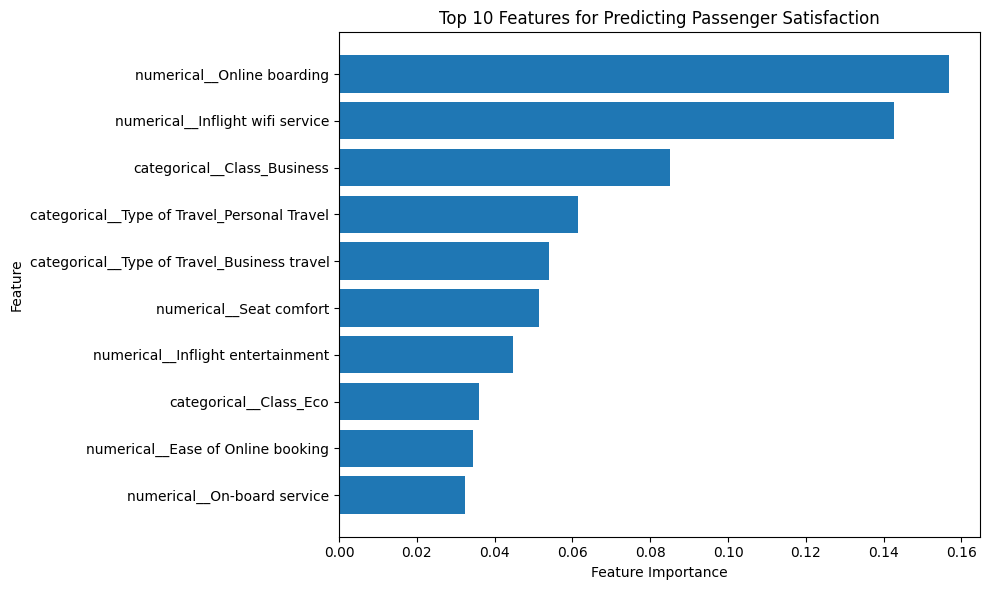

In [19]:
import matplotlib.pyplot as plt

top_10_features = importance_df.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.title("Top 10 Features for Predicting Passenger Satisfaction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Conclusion

The machine-learning analysis demonstrated that passenger satisfaction can be predicted effectively using passenger characteristics, travel information and service-rating variables.

A baseline classifier achieved approximately **56.7% accuracy**, providing a benchmark for evaluating the predictive models.

Logistic Regression achieved **87.18% accuracy**, showing that the selected features contain substantial predictive information. However, the Random Forest classifier performed considerably better, achieving **96.42% accuracy** together with strong precision, recall and F1-scores for both satisfaction classes.

Random Forest was therefore selected as the final model because it provided the strongest overall predictive performance among the models evaluated.

Feature importance analysis identified **Online boarding** and **Inflight wifi service** as the two most influential predictors. Travel characteristics including **Class** and **Type of Travel** were also important, alongside service factors such as **Seat comfort**, **Inflight entertainment**, **Ease of Online booking**, and **On-board service**.

These results support findings from the exploratory and statistical analyses and suggest that both the digital travel experience and onboard service quality are important indicators of passenger satisfaction.

The model results demonstrate predictive relationships within this dataset and should not be interpreted as evidence that individual features directly cause passenger satisfaction.

## Business Implications

The analysis suggests that airlines seeking to improve passenger satisfaction should pay particular attention to the digital passenger journey, especially online boarding and inflight WiFi services. Improvements to seat comfort, entertainment and onboard service may also contribute to a better passenger experience.

Differences associated with travel class and type of travel indicate that satisfaction patterns vary across passenger segments. These segments could therefore be considered when designing targeted service-improvement strategies.

## Next Steps

The selected Random Forest model and the key analytical findings can be incorporated into the interactive project to communicate passenger satisfaction patterns, model performance and important predictors to stakeholders.